In [1]:
# Step 1 - Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("Setup complete ✓")

pandas: 2.3.3
numpy: 2.3.5
Setup complete ✓


In [3]:
# Step 2 - Load & First Look
df = pd.read_csv('C:\\HealthcareML_Platform\\02_Data\\raw\\meningitis_dataset.csv')


print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

Shape: (284484, 40)

Columns: ['id', 'surname', 'firstname', 'middlename', 'gender', 'gender_male', 'gender_female', 'state', 'settlement', 'rural_settlement', 'urban_settlement', 'report_date', 'report_year', 'age', 'age_str', 'date_of_birth', 'child_group', 'adult_group', 'disease', 'cholera', 'diarrhoea', 'measles', 'viral_haemmorrhaphic_fever', 'meningitis', 'ebola', 'marburg_virus', 'yellow_fever', 'rubella_mars', 'malaria', 'serotype', 'NmA', 'NmC', 'NmW', 'health_status', 'alive', 'dead', 'report_outcome', 'unconfirmed', 'confirmed', 'null_serotype']

Dtypes:
 id                             int64
surname                       object
firstname                     object
middlename                    object
gender                        object
gender_male                    int64
gender_female                  int64
state                         object
settlement                    object
rural_settlement               int64
urban_settlement               int64
report_date        

In [4]:
# Step 3 - Null Check & Basic Stats
print("Null values:\n", df.isnull().sum())
print("\nTotal nulls:", df.isnull().sum().sum())
print("\nUnique diseases:", df['disease'].unique())
print("\nUnique states:", df['state'].nunique(), "states")
print("\nDate range:", df['report_date'].min(), "to", df['report_date'].max())
print("\nReport years:", sorted(df['report_year'].unique()))

Null values:
 id                            0
surname                       0
firstname                     0
middlename                    0
gender                        0
gender_male                   0
gender_female                 0
state                         0
settlement                    0
rural_settlement              0
urban_settlement              0
report_date                   0
report_year                   0
age                           0
age_str                       0
date_of_birth                 0
child_group                   0
adult_group                   0
disease                       0
cholera                       0
diarrhoea                     0
measles                       0
viral_haemmorrhaphic_fever    0
meningitis                    0
ebola                         0
marburg_virus                 0
yellow_fever                  0
rubella_mars                  0
malaria                       0
serotype                      0
NmA                       

In [5]:
# Step 4 - Fix Dates & Clean
# Fix bad dates
df['report_date'] = pd.to_datetime(df['report_date'], errors='coerce')

# Drop rows with bad dates
before = len(df)
df = df.dropna(subset=['report_date'])
after = len(df)

# Standardize text columns
df['disease'] = df['disease'].str.strip().str.title()
df['state'] = df['state'].str.strip().str.title()
df['health_status'] = df['health_status'].str.strip().str.lower()
df['report_outcome'] = df['report_outcome'].str.strip().str.lower()

print(f"Rows before: {before}")
print(f"Rows after: {after}")
print(f"Dropped: {before - after}")
print("\nDate range:", df['report_date'].min(), "to", df['report_date'].max())
print("\nDisease counts:\n", df['disease'].value_counts())

Rows before: 284484
Rows after: 283112
Dropped: 1372

Date range: 2009-01-01 00:00:00 to 2018-12-31 00:00:00

Disease counts:
 disease
Cholera                       28440
Rubella Mars                  28409
Malaria                       28401
Diarrhoea                     28398
Measles                       28354
Marburg Virus                 28303
Yellow Fever                  28278
Viral Haemmorrhaphic Fever    28278
Meningitis                    28224
Ebola                         28027
Name: count, dtype: int64


In [6]:
# Step 5 - Aggregate to Daily Time Series
daily_df = df.groupby(['report_date', 'disease', 'state']).agg(
    cases=('id', 'count'),
    deaths=('dead', 'sum'),
    confirmed=('confirmed', 'sum')
).reset_index()

# Sort by date
daily_df = daily_df.sort_values('report_date').reset_index(drop=True)

print("Daily time series shape:", daily_df.shape)
print("\nSample:\n", daily_df.head(10))
print("\nDate range:", daily_df['report_date'].min(), "to", daily_df['report_date'].max())
print("\nAvg daily cases per disease-state:", round(daily_df['cases'].mean(), 2))
print("\nMax daily cases:", daily_df['cases'].max())

Daily time series shape: (255270, 6)

Sample:
   report_date       disease        state  cases  deaths  confirmed
0  2009-01-01       Cholera      Anambra      1       0          0
1  2009-01-01  Rubella Mars         Ondo      2       0          0
2  2009-01-01  Rubella Mars        Lagos      1       0          0
3  2009-01-01  Rubella Mars        Kebbi      1       1          0
4  2009-01-01  Rubella Mars        Gombe      2       0          0
5  2009-01-01  Rubella Mars       Ebonyi      2       2          0
6  2009-01-01  Rubella Mars  Cross River      1       0          0
7  2009-01-01  Rubella Mars         Osun      1       0          0
8  2009-01-01  Rubella Mars        Benue      1       1          0
9  2009-01-01    Meningitis         Ondo      1       1          0

Date range: 2009-01-01 00:00:00 to 2018-12-31 00:00:00

Avg daily cases per disease-state: 1.11

Max daily cases: 6


In [7]:
# Step 6 - Create Disease-Level Daily Aggregation
disease_daily = df.groupby(['report_date', 'disease']).agg(
    cases=('id', 'count'),
    deaths=('dead', 'sum'),
    confirmed=('confirmed', 'sum')
).reset_index().sort_values('report_date').reset_index(drop=True)

print("Shape:", disease_daily.shape)
print("\nSample:\n", disease_daily.head(10))
print("\nAvg daily cases per disease:", round(disease_daily['cases'].mean(), 2))
print("\nMax daily cases:", disease_daily['cases'].max())
print("\nCases stats:\n", disease_daily['cases'].describe())

Shape: (36500, 5)

Sample:
   report_date                     disease  cases  deaths  confirmed
0  2009-01-01                     Cholera     12       5          2
1  2009-01-01                   Diarrhoea     10       5          6
2  2009-01-01                       Ebola      5       3          0
3  2009-01-01                     Malaria      5       1          2
4  2009-01-01               Marburg Virus      7       4          0
5  2009-01-01                     Measles      5       0          2
6  2009-01-01                  Meningitis      4       4          0
7  2009-01-01                Rubella Mars     13       4          0
8  2009-01-01  Viral Haemmorrhaphic Fever     12       9          0
9  2009-01-01                Yellow Fever      9       8          7

Avg daily cases per disease: 7.76

Max daily cases: 20

Cases stats:
 count    36500.000000
mean         7.756493
std          2.772168
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000

In [10]:
# Save processed daily dataset
disease_daily.to_csv('C:\\HealthcareML_Platform\\02_Data\\processed\\disease_daily.csv', index=False)
print("Saved disease_daily.csv ✓")

Saved disease_daily.csv ✓


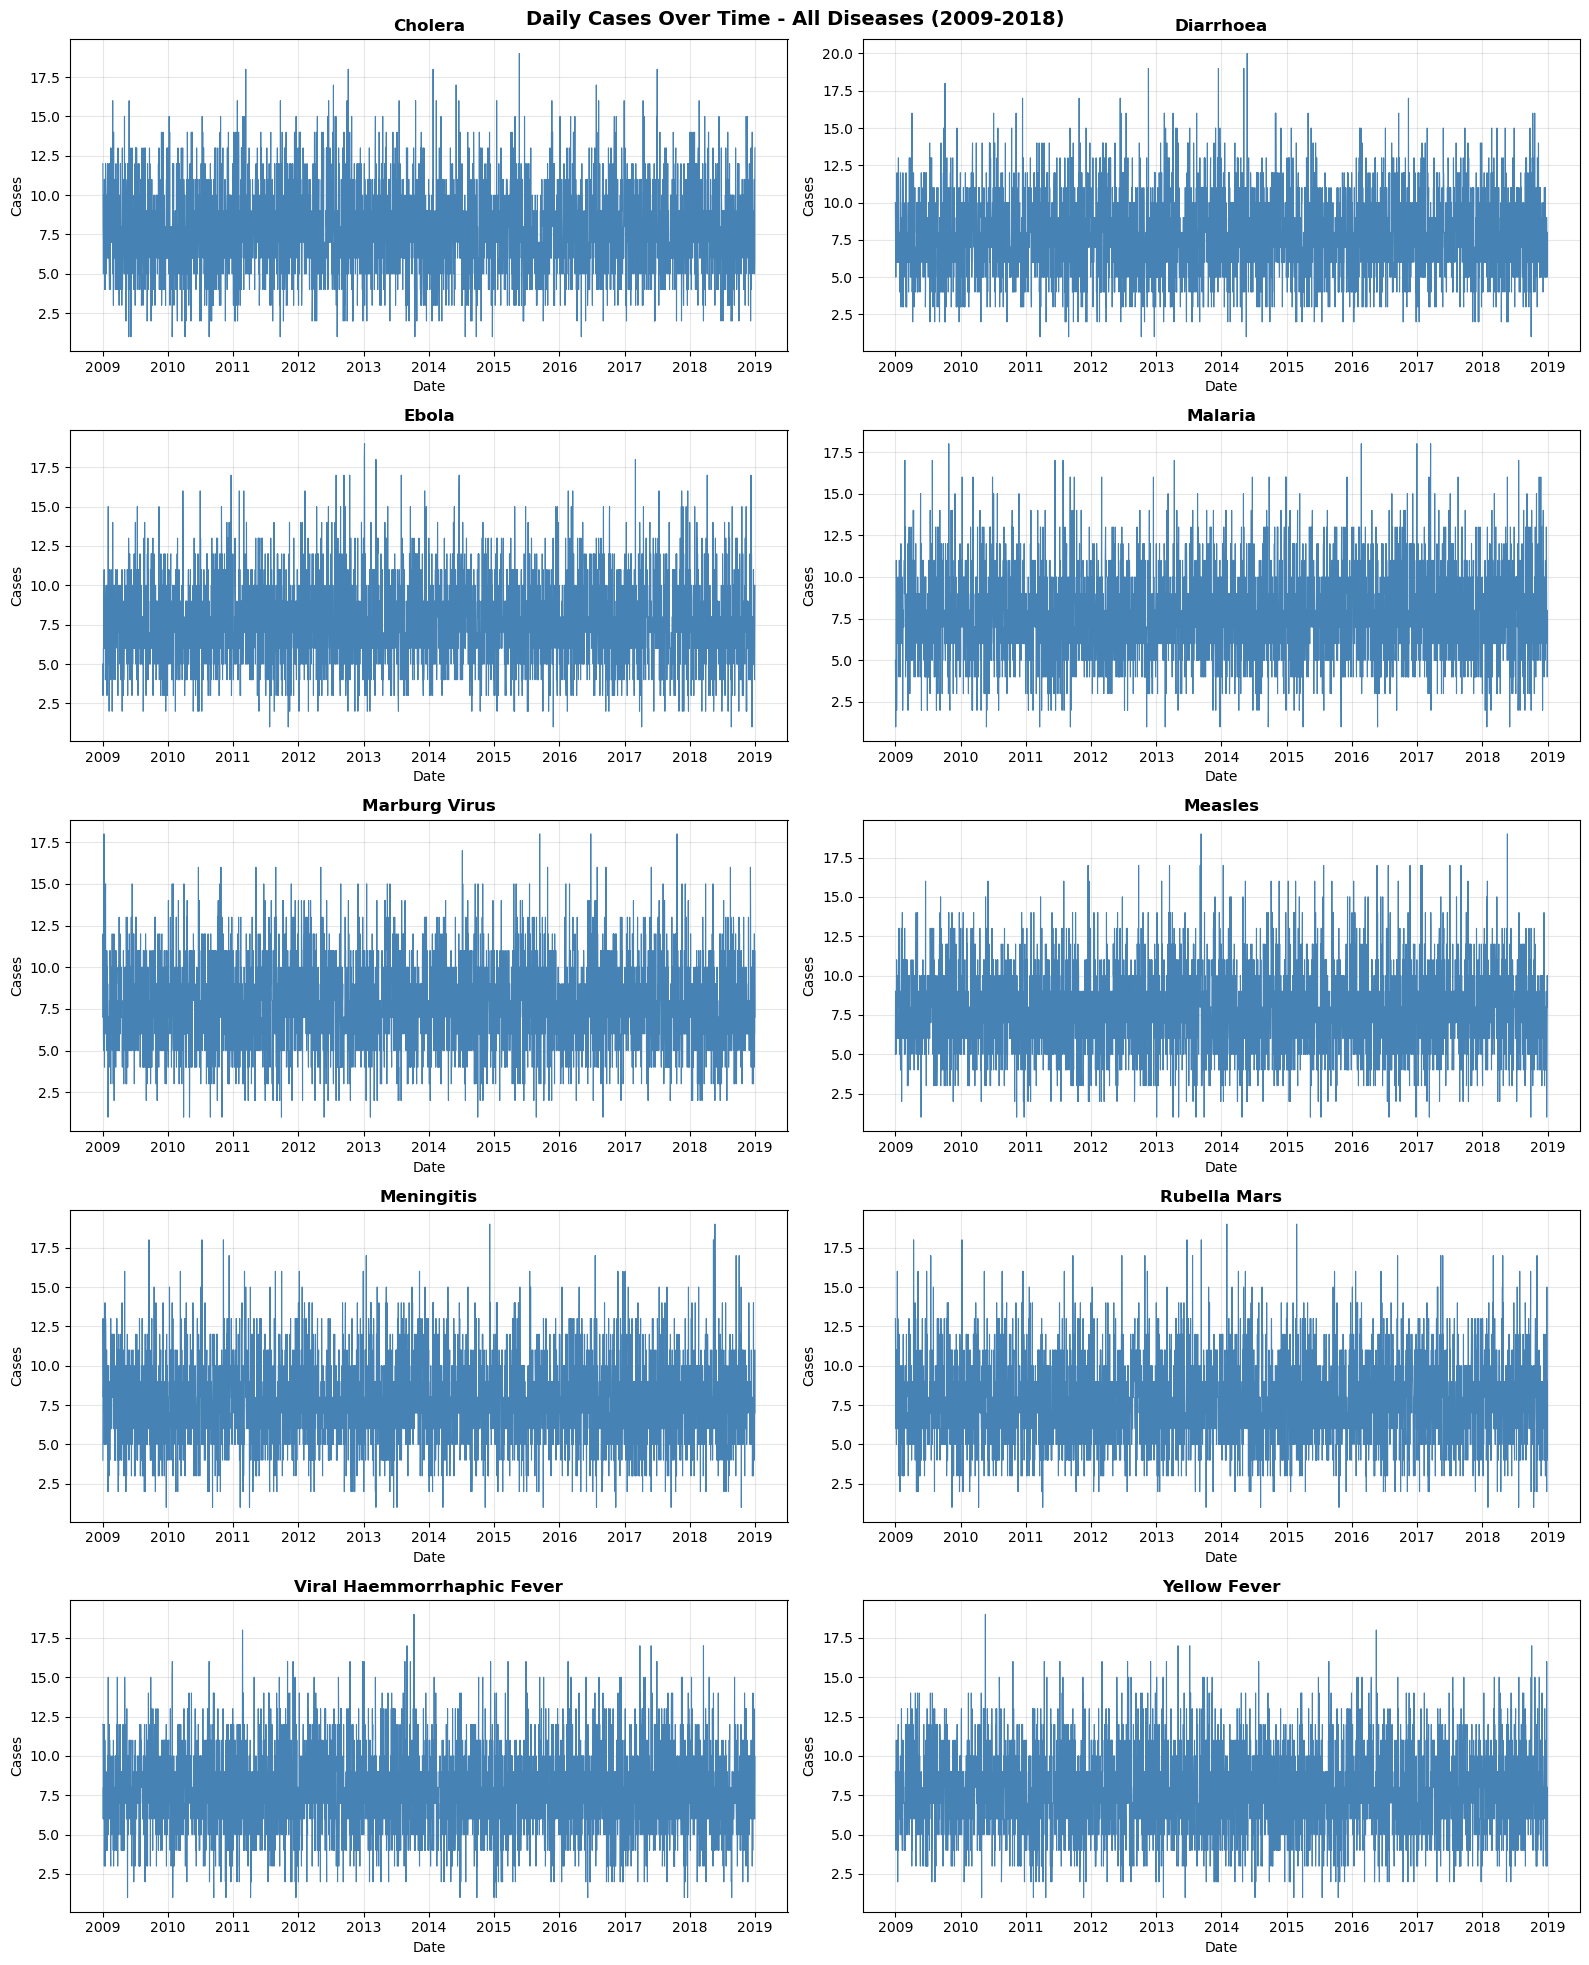

Plot saved ✓


In [8]:
# Step 7 - EDA: Cases Over Time Per Disease
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

diseases = disease_daily['disease'].unique()

for i, disease in enumerate(diseases):
    data = disease_daily[disease_daily['disease'] == disease]
    axes[i].plot(data['report_date'], data['cases'], linewidth=0.8, color='steelblue')
    axes[i].set_title(disease, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Cases')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Daily Cases Over Time - All Diseases (2009-2018)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\02_Data\\processed\\eda_cases_over_time.png', dpi=150)
plt.show()
print("Plot saved ✓")

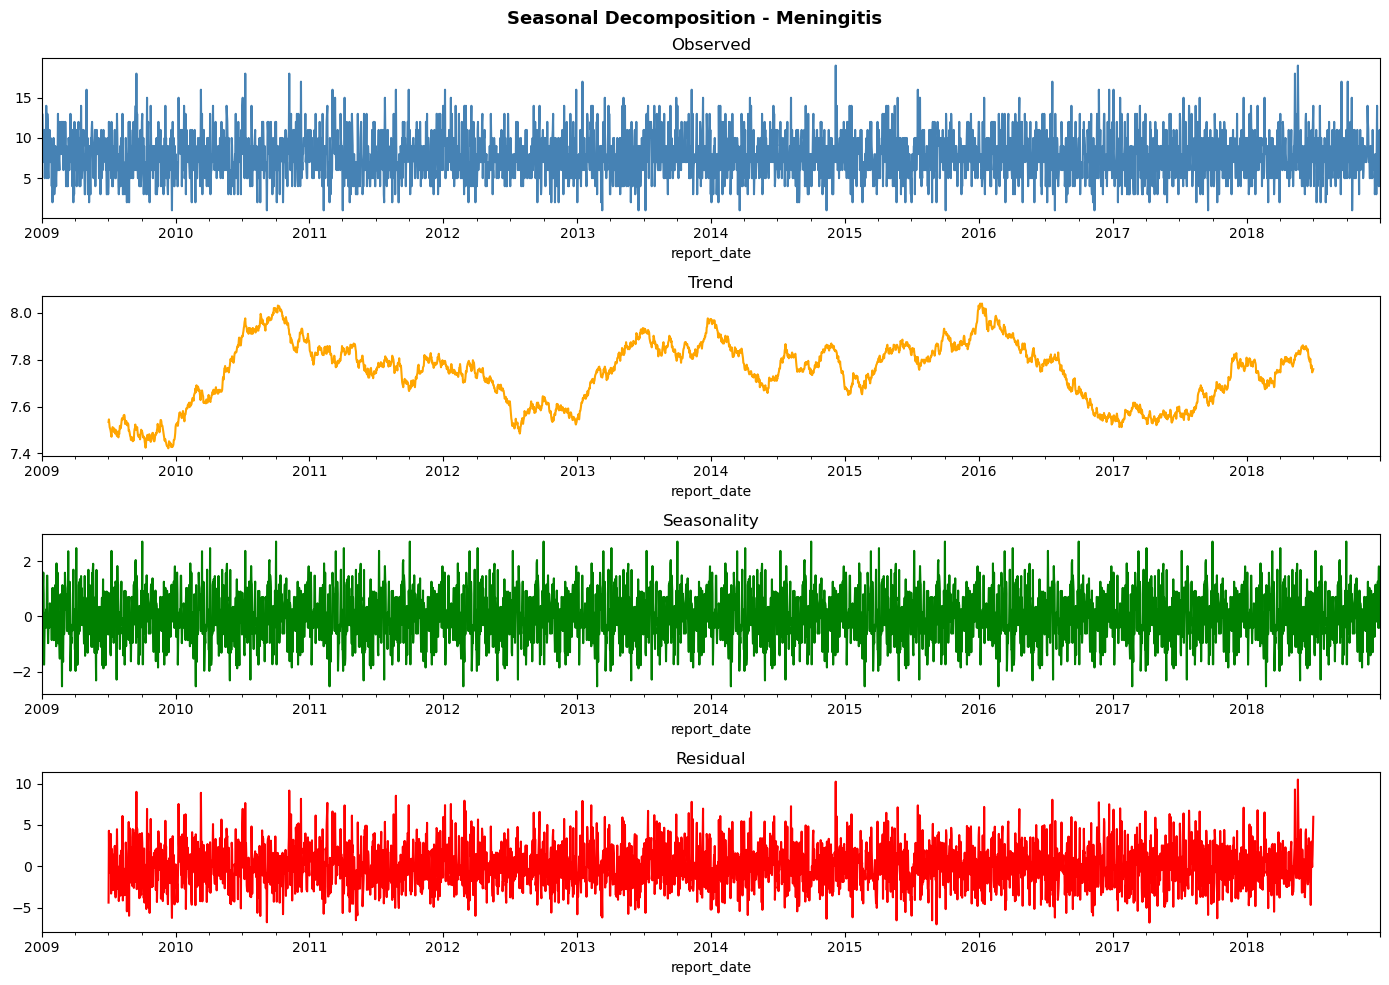

Decomposition done ✓


In [9]:
# Step 8 - Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Use Meningitis as example
mening = disease_daily[disease_daily['disease'] == 'Meningitis'].set_index('report_date')['cases']
mening = mening.asfreq('D').fillna(method='ffill')

decomp = seasonal_decompose(mening, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], title='Observed', color='steelblue')
decomp.trend.plot(ax=axes[1], title='Trend', color='orange')
decomp.seasonal.plot(ax=axes[2], title='Seasonality', color='green')
decomp.resid.plot(ax=axes[3], title='Residual', color='red')

plt.suptitle('Seasonal Decomposition - Meningitis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\02_Data\\processed\\eda_decomposition.png', dpi=150)
plt.show()
print("Decomposition done ✓")

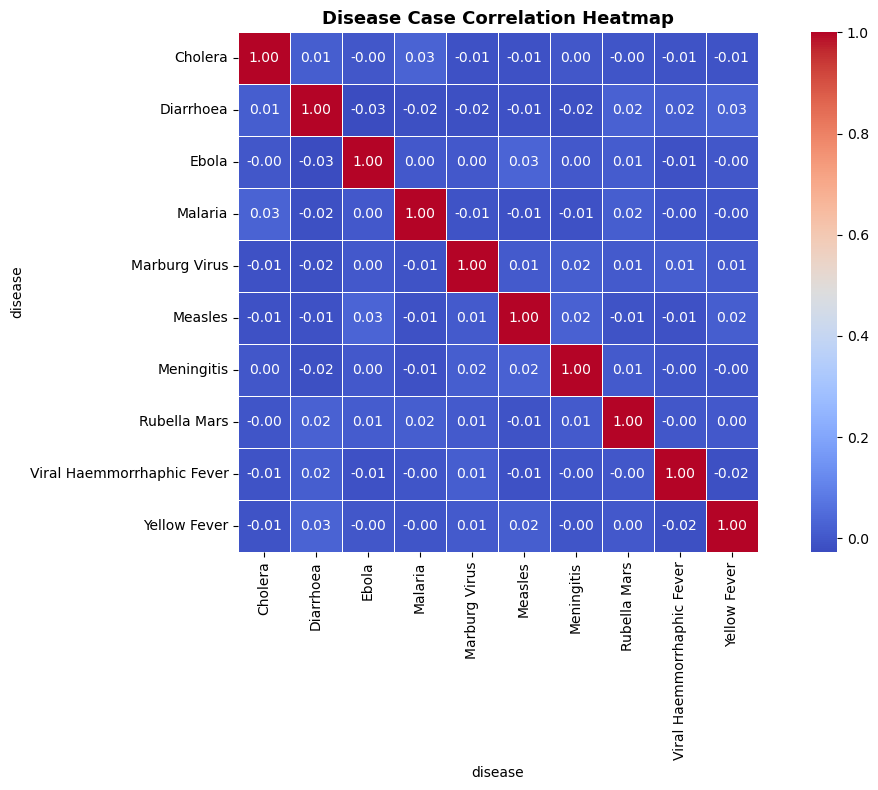

Correlation heatmap done ✓


In [11]:
# Step 9 - Correlation Heatmap
pivot = disease_daily.pivot_table(
    index='report_date', 
    columns='disease', 
    values='cases'
).fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Disease Case Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\02_Data\\processed\\eda_correlation.png', dpi=150)
plt.show()
print("Correlation heatmap done ✓")

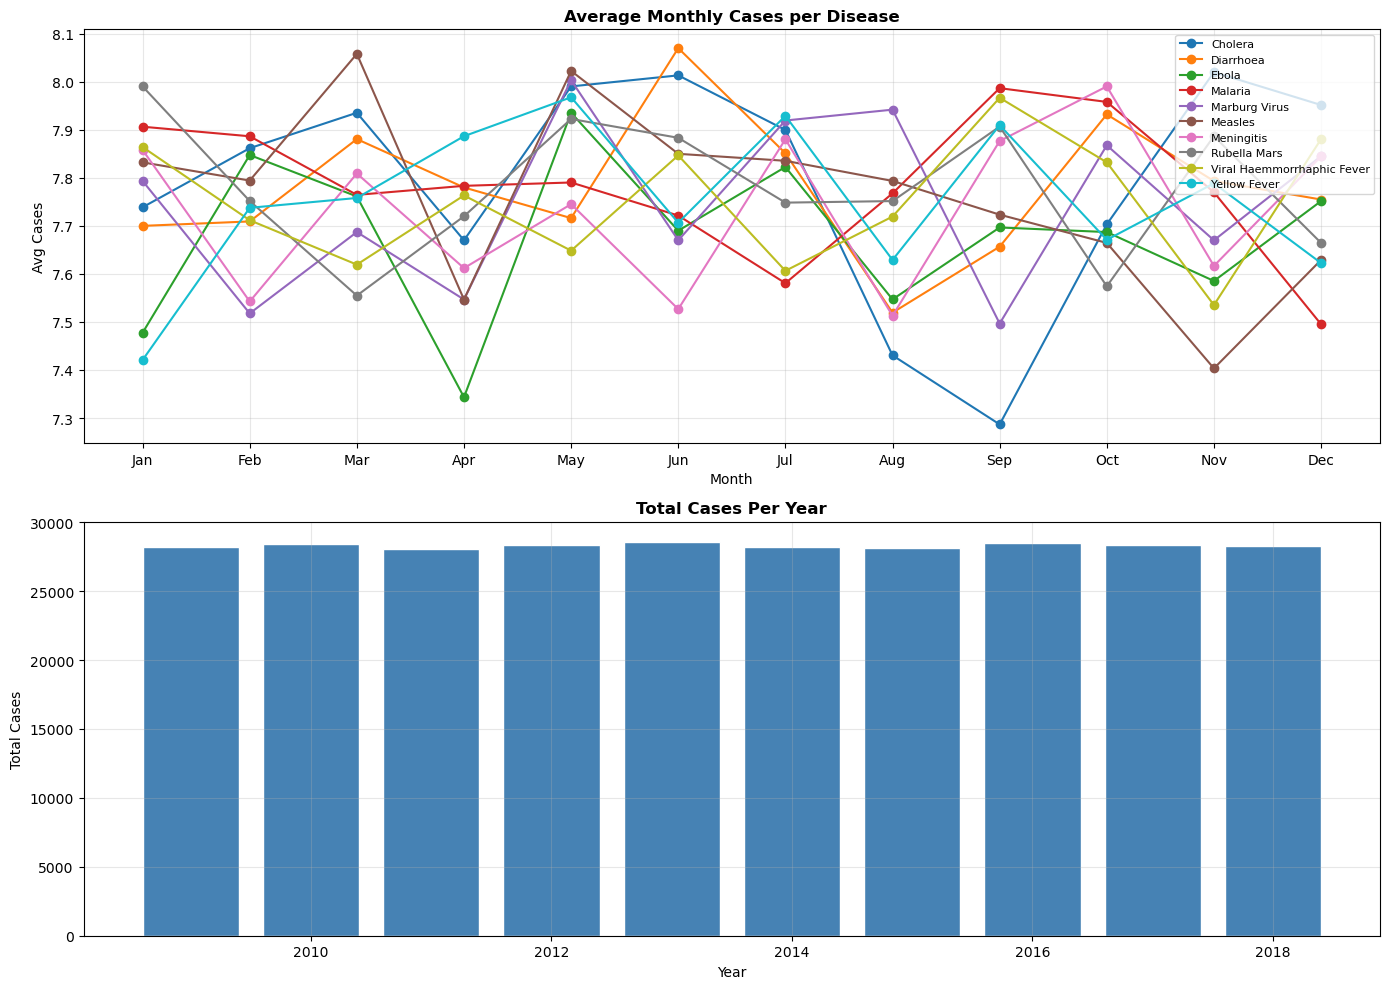

Monthly analysis done ✓


In [12]:
# Step 10 - Monthly Aggregation Analysis
disease_daily['month'] = disease_daily['report_date'].dt.month
disease_daily['year'] = disease_daily['report_date'].dt.year
disease_daily['dayofweek'] = disease_daily['report_date'].dt.dayofweek

monthly = disease_daily.groupby(['year', 'month', 'disease'])['cases'].sum().reset_index()
monthly_avg = disease_daily.groupby(['month', 'disease'])['cases'].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Monthly average cases per disease
for disease in disease_daily['disease'].unique():
    data = monthly_avg[monthly_avg['disease'] == disease]
    axes[0].plot(data['month'], data['cases'], marker='o', label=disease, linewidth=1.5)

axes[0].set_title('Average Monthly Cases per Disease', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Cases')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(True, alpha=0.3)

# Yearly total cases
yearly = disease_daily.groupby('year')['cases'].sum().reset_index()
axes[1].bar(yearly['year'], yearly['cases'], color='steelblue', edgecolor='white')
axes[1].set_title('Total Cases Per Year', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Cases')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\02_Data\\processed\\eda_monthly_yearly.png', dpi=150)
plt.show()
print("Monthly analysis done ✓")

In [13]:
# Step 11 - Feature Engineering
df_feat = disease_daily.copy()

# Sort properly
df_feat = df_feat.sort_values(['disease', 'report_date']).reset_index(drop=True)

# Rolling statistics per disease
df_feat['rolling_7d_mean'] = df_feat.groupby('disease')['cases'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df_feat['rolling_14d_mean'] = df_feat.groupby('disease')['cases'].transform(lambda x: x.rolling(14, min_periods=1).mean())
df_feat['rolling_30d_mean'] = df_feat.groupby('disease')['cases'].transform(lambda x: x.rolling(30, min_periods=1).mean())
df_feat['rolling_7d_std'] = df_feat.groupby('disease')['cases'].transform(lambda x: x.rolling(7, min_periods=1).std().fillna(0))

# Lag features
df_feat['lag_1'] = df_feat.groupby('disease')['cases'].shift(1).fillna(0)
df_feat['lag_3'] = df_feat.groupby('disease')['cases'].shift(3).fillna(0)
df_feat['lag_7'] = df_feat.groupby('disease')['cases'].shift(7).fillna(0)
df_feat['lag_14'] = df_feat.groupby('disease')['cases'].shift(14).fillna(0)

# Growth rates
df_feat['growth_rate_1d'] = df_feat.groupby('disease')['cases'].pct_change(1).fillna(0)
df_feat['growth_rate_7d'] = df_feat.groupby('disease')['cases'].pct_change(7).fillna(0)

# Spike ratio
df_feat['spike_ratio'] = df_feat['cases'] / (df_feat['rolling_30d_mean'] + 0.001)

# Time features
df_feat['dayofweek'] = df_feat['report_date'].dt.dayofweek
df_feat['month'] = df_feat['report_date'].dt.month
df_feat['season'] = df_feat['month'].map({12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3})

print("Feature engineering done ✓")
print("Shape:", df_feat.shape)
print("\nNew features:", df_feat.columns.tolist())
print("\nSample:\n", df_feat.head(3))

Feature engineering done ✓
Shape: (36500, 20)

New features: ['report_date', 'disease', 'cases', 'deaths', 'confirmed', 'month', 'year', 'dayofweek', 'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std', 'lag_1', 'lag_3', 'lag_7', 'lag_14', 'growth_rate_1d', 'growth_rate_7d', 'spike_ratio', 'season']

Sample:
   report_date  disease  cases  deaths  confirmed  month  year  dayofweek  \
0  2009-01-01  Cholera     12       5          2      1  2009          3   
1  2009-01-02  Cholera      8       3          4      1  2009          4   
2  2009-01-03  Cholera      7       4          6      1  2009          5   

   rolling_7d_mean  rolling_14d_mean  rolling_30d_mean  rolling_7d_std  lag_1  \
0             12.0              12.0              12.0        0.000000    0.0   
1             10.0              10.0              10.0        2.828427   12.0   
2              9.0               9.0               9.0        2.645751    8.0   

   lag_3  lag_7  lag_14  growth_rat

In [14]:
# Step 12 - Create Outbreak Labels
# Outbreak = cases > mean + 2*std (per disease)
stats = df_feat.groupby('disease')['cases'].agg(['mean', 'std']).reset_index()
stats['threshold'] = stats['mean'] + 2 * stats['std']

df_feat = df_feat.merge(stats[['disease', 'threshold']], on='disease', how='left')

# Label outbreaks
df_feat['is_outbreak'] = (df_feat['cases'] >= df_feat['threshold']).astype(int)

# Alert levels
df_feat['alert_level'] = 'Normal'
df_feat.loc[df_feat['cases'] >= stats['threshold'].mean(), 'alert_level'] = 'Watch'
df_feat.loc[df_feat['is_outbreak'] == 1, 'alert_level'] = 'Outbreak'

print("Outbreak labels created ✓")
print("\nThresholds per disease:\n", stats[['disease', 'mean', 'std', 'threshold']])
print("\nOutbreak distribution:\n", df_feat['is_outbreak'].value_counts())
print("\nAlert levels:\n", df_feat['alert_level'].value_counts())

Outbreak labels created ✓

Thresholds per disease:
                       disease      mean       std  threshold
0                     Cholera  7.791781  2.844261  13.480303
1                   Diarrhoea  7.780274  2.766207  13.312687
2                       Ebola  7.678630  2.734534  13.147697
3                     Malaria  7.783228  2.748681  13.280589
4               Marburg Virus  7.750000  2.718751  13.187501
5                     Measles  7.763965  2.798273  13.360511
6                  Meningitis  7.736842  2.773378  13.283599
7                Rubella Mars  7.779025  2.801019  13.381063
8  Viral Haemmorrhaphic Fever  7.749520  2.764667  13.278854
9                Yellow Fever  7.751645  2.771481  13.294606

Outbreak distribution:
 is_outbreak
0    35551
1      949
Name: count, dtype: int64

Alert levels:
 alert_level
Normal      35551
Outbreak      949
Name: count, dtype: int64


In [15]:
# Step 13 - Isolation Forest Training
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Features for isolation forest
iso_features = ['cases', 'rolling_7d_mean', 'rolling_14d_mean', 
                'rolling_30d_mean', 'rolling_7d_std', 'spike_ratio',
                'growth_rate_1d', 'growth_rate_7d', 'lag_1', 'lag_7']

X_iso = df_feat[iso_features].fillna(0)

# Scale
scaler_iso = StandardScaler()
X_iso_scaled = scaler_iso.fit_transform(X_iso)

# Train Isolation Forest
iso_model = IsolationForest(contamination=0.026, random_state=42, n_estimators=100)
iso_model.fit(X_iso_scaled)

# Predictions
df_feat['anomaly_score'] = -iso_model.score_samples(X_iso_scaled)
df_feat['iso_prediction'] = iso_model.predict(X_iso_scaled)
df_feat['iso_outbreak'] = (df_feat['iso_prediction'] == -1).astype(int)

print("Isolation Forest trained ✓")
print("\nAnomaly score stats:\n", df_feat['anomaly_score'].describe())
print("\nDetected outbreaks:", df_feat['iso_outbreak'].sum())
print("Actual outbreaks:", df_feat['is_outbreak'].sum())

Isolation Forest trained ✓

Anomaly score stats:
 count    36500.000000
mean         0.443841
std          0.045979
min          0.369844
25%          0.410101
50%          0.433134
75%          0.467088
max          0.707190
Name: anomaly_score, dtype: float64

Detected outbreaks: 949
Actual outbreaks: 949


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     35551
           1       0.39      0.39      0.39       949

    accuracy                           0.97     36500
   macro avg       0.69      0.69      0.69     36500
weighted avg       0.97      0.97      0.97     36500



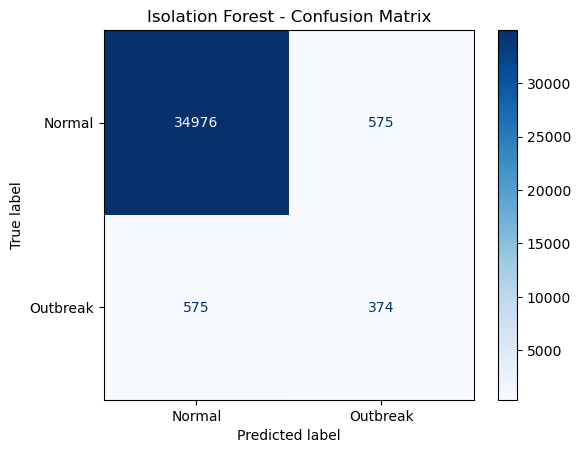

In [16]:
# Step 14 - Evaluate Isolation Forest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Classification Report:")
print(classification_report(df_feat['is_outbreak'], df_feat['iso_outbreak']))

cm = confusion_matrix(df_feat['is_outbreak'], df_feat['iso_outbreak'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Outbreak'])
disp.plot(cmap='Blues')
plt.title('Isolation Forest - Confusion Matrix')
plt.savefig('C:\\HealthcareML_Platform\\02_Data\\processed\\iso_confusion_matrix.png', dpi=150)
plt.show()

In [17]:
# Step 15 - Save Isolation Forest Model
import joblib

joblib.dump(iso_model, 'C:\\HealthcareML_Platform\\03_Models\\isolation_forest_outbreak.pkl')
joblib.dump(scaler_iso, 'C:\\HealthcareML_Platform\\03_Models\\outbreak_iso_scaler.pkl')
joblib.dump(iso_features, 'C:\\HealthcareML_Platform\\03_Models\\iso_feature_names.pkl')

print("Isolation Forest saved ✓")
print("Scaler saved ✓")
print("Feature names saved ✓")

Isolation Forest saved ✓
Scaler saved ✓
Feature names saved ✓


In [18]:
# Step 16 - Install & Import Prophet
!pip install prophet -q

from prophet import Prophet
print("Prophet imported ✓")

Prophet imported ✓


In [19]:
# Step 17 - Prepare Prophet Data & Train
prophet_models = {}

diseases = disease_daily['disease'].unique()

for disease in diseases:
    data = disease_daily[disease_daily['disease'] == disease][['report_date', 'cases']].copy()
    data.columns = ['ds', 'y']
    
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.fit(data)
    prophet_models[disease] = model

print("Prophet trained for all diseases")
print("Total models:", len(prophet_models))

12:08:32 - cmdstanpy - INFO - Chain [1] start processing
12:08:33 - cmdstanpy - INFO - Chain [1] done processing
12:08:33 - cmdstanpy - INFO - Chain [1] start processing
12:08:34 - cmdstanpy - INFO - Chain [1] done processing
12:08:34 - cmdstanpy - INFO - Chain [1] start processing
12:08:34 - cmdstanpy - INFO - Chain [1] done processing
12:08:34 - cmdstanpy - INFO - Chain [1] start processing
12:08:34 - cmdstanpy - INFO - Chain [1] done processing
12:08:35 - cmdstanpy - INFO - Chain [1] start processing
12:08:35 - cmdstanpy - INFO - Chain [1] done processing
12:08:35 - cmdstanpy - INFO - Chain [1] start processing
12:08:35 - cmdstanpy - INFO - Chain [1] done processing
12:08:36 - cmdstanpy - INFO - Chain [1] start processing
12:08:36 - cmdstanpy - INFO - Chain [1] done processing
12:08:36 - cmdstanpy - INFO - Chain [1] start processing
12:08:36 - cmdstanpy - INFO - Chain [1] done processing
12:08:37 - cmdstanpy - INFO - Chain [1] start processing
12:08:37 - cmdstanpy - INFO - Chain [1]

Prophet trained for all diseases
Total models: 10


In [20]:
# Step 18 - Generate 14-Day Forecast & Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = {}

for disease in diseases:
    data = disease_daily[disease_daily['disease'] == disease][['report_date', 'cases']].copy()
    data.columns = ['ds', 'y']
    
    future = prophet_models[disease].make_future_dataframe(periods=14)
    forecast = prophet_models[disease].predict(future)
    
    merged = data.merge(forecast[['ds', 'yhat']], on='ds')
    mae = mean_absolute_error(merged['y'], merged['yhat'])
    rmse = mean_squared_error(merged['y'], merged['yhat']) ** 0.5
    
    results[disease] = {'MAE': round(mae, 2), 'RMSE': round(rmse, 2)}

results_df = pd.DataFrame(results).T
print("Prophet Evaluation:\n", results_df)
print("\nAvg MAE:", round(results_df['MAE'].mean(), 2))
print("Avg RMSE:", round(results_df['RMSE'].mean(), 2))

Prophet Evaluation:
                              MAE  RMSE
Cholera                     2.26  2.83
Diarrhoea                   2.19  2.75
Ebola                       2.17  2.72
Malaria                     2.18  2.74
Marburg Virus               2.16  2.71
Measles                     2.23  2.79
Meningitis                  2.20  2.76
Rubella Mars                2.23  2.79
Viral Haemmorrhaphic Fever  2.20  2.76
Yellow Fever                2.23  2.76

Avg MAE: 2.2
Avg RMSE: 2.76


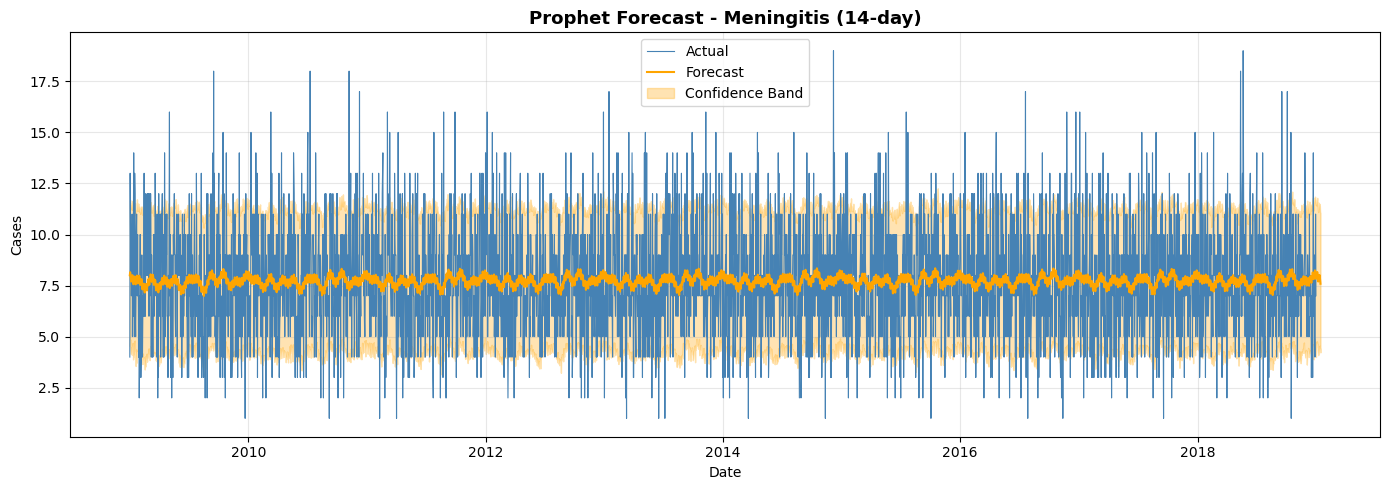

In [21]:
# Step 19 - Plot Prophet Forecast
disease = 'Meningitis'
data = disease_daily[disease_daily['disease'] == disease][['report_date', 'cases']].copy()
data.columns = ['ds', 'y']

future = prophet_models[disease].make_future_dataframe(periods=14)
forecast = prophet_models[disease].predict(future)

plt.figure(figsize=(14, 5))
plt.plot(data['ds'], data['y'], color='steelblue', linewidth=0.8, label='Actual')
plt.plot(forecast['ds'], forecast['yhat'], color='orange', linewidth=1.5, label='Forecast')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], alpha=0.3, color='orange', label='Confidence Band')
plt.title('Prophet Forecast - Meningitis (14-day)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\02_Data\\processed\\prophet_forecast.png', dpi=150)
plt.show()

In [25]:
# Step 20 - LSTM Data Preparation
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

LOOKBACK = 14
FORECAST = 7

lstm_scalers = {}
lstm_data = {}

for disease in diseases:
    data = disease_daily[disease_daily['disease'] == disease]['cases'].values.reshape(-1, 1)
    
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(data)
    lstm_scalers[disease] = scaler
    
    X, y = [], []
    for i in range(LOOKBACK, len(scaled) - FORECAST):
        X.append(scaled[i-LOOKBACK:i, 0])
        y.append(scaled[i:i+FORECAST, 0])
    
    lstm_data[disease] = (np.array(X), np.array(y))

X_sample, y_sample = lstm_data['Meningitis']
print("LSTM data prepared")
print("X shape:", X_sample.shape)
print("y shape:", y_sample.shape)

LSTM data prepared
X shape: (3627, 14)
y shape: (3627, 7)


In [26]:
# Step 21 - Build & Train LSTM
from tensorflow.keras.callbacks import EarlyStopping

lstm_models = {}

for disease in diseases:
    X, y = lstm_data[disease]
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split].reshape(-1, LOOKBACK, 1), X[split:].reshape(-1, LOOKBACK, 1)
    y_train, y_test = y[:split], y[split:]

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(FORECAST)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=50, batch_size=32,
              validation_data=(X_test, y_test),
              callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
              verbose=0)
    lstm_models[disease] = model

print("LSTM trained for all diseases")
print("Total models:", len(lstm_models))

LSTM trained for all diseases
Total models: 10


In [27]:
# Step 22 - Evaluate LSTM
lstm_results = {}

for disease in diseases:
    X, y = lstm_data[disease]
    split = int(len(X) * 0.8)
    X_test = X[split:].reshape(-1, LOOKBACK, 1)
    y_test = y[split:]

    scaler = lstm_scalers[disease]
    y_pred = lstm_models[disease].predict(X_test, verbose=0)

    y_test_inv = scaler.inverse_transform(y_test)
    y_pred_inv = scaler.inverse_transform(y_pred)

    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = mean_squared_error(y_test_inv, y_pred_inv) ** 0.5
    lstm_results[disease] = {'MAE': round(mae, 2), 'RMSE': round(rmse, 2)}

lstm_results_df = pd.DataFrame(lstm_results).T
print("LSTM Evaluation:\n", lstm_results_df)
print("\nAvg MAE:", round(lstm_results_df['MAE'].mean(), 2))
print("Avg RMSE:", round(lstm_results_df['RMSE'].mean(), 2))

LSTM Evaluation:
                              MAE  RMSE
Cholera                     2.27  2.80
Diarrhoea                   2.14  2.68
Ebola                       2.27  2.87
Malaria                     2.26  2.83
Marburg Virus               2.17  2.69
Measles                     2.19  2.78
Meningitis                  2.20  2.78
Rubella Mars                2.26  2.82
Viral Haemmorrhaphic Fever  2.22  2.79
Yellow Fever                2.14  2.68

Avg MAE: 2.21
Avg RMSE: 2.77


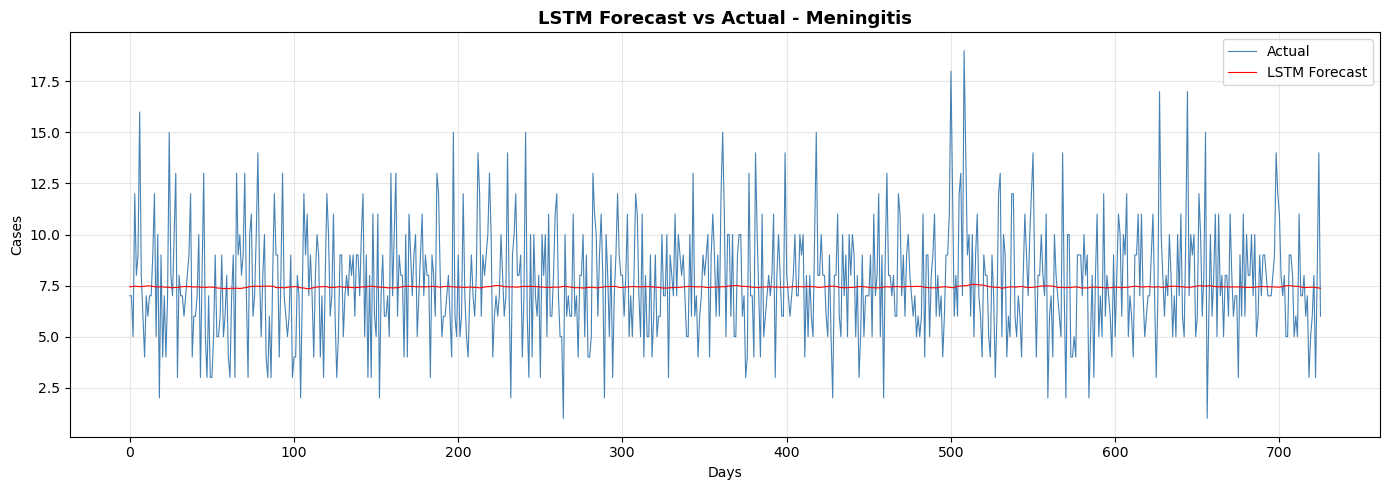

In [28]:
# Step 23 - Plot LSTM Forecast vs Actual
disease = 'Meningitis'
X, y = lstm_data[disease]
split = int(len(X) * 0.8)
X_test = X[split:].reshape(-1, LOOKBACK, 1)
y_test = y[split:]

scaler = lstm_scalers[disease]
y_pred = lstm_models[disease].predict(X_test, verbose=0)

y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

plt.figure(figsize=(14, 5))
plt.plot(y_test_inv[:, 0], label='Actual', color='steelblue', linewidth=0.8)
plt.plot(y_pred_inv[:, 0], label='LSTM Forecast', color='red', linewidth=0.8)
plt.title('LSTM Forecast vs Actual - Meningitis', fontsize=13, fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Cases')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\02_Data\\processed\\lstm_forecast.png', dpi=150)
plt.show()

In [29]:
# Step 24 - Outbreak Alert System
def get_alert_level(cases, disease, df_feat):
    stats = df_feat[df_feat['disease'] == disease]['cases']
    mean = stats.mean()
    std = stats.std()
    
    if cases >= mean + 2 * std:
        return 'Outbreak', round((cases - mean) / std, 2)
    elif cases >= mean + std:
        return 'Watch', round((cases - mean) / std, 2)
    else:
        return 'Normal', round((cases - mean) / std, 2)

# Test on 5 scenarios
test_cases = [
    ('Meningitis', 5),
    ('Meningitis', 10),
    ('Meningitis', 16),
    ('Cholera', 18),
    ('Malaria', 8)
]

print("Alert System Test:")
print(f"{'Disease':<30} {'Cases':<10} {'Alert':<10} {'Score'}")
print("-" * 60)
for disease, cases in test_cases:
    alert, score = get_alert_level(cases, disease, df_feat)
    print(f"{disease:<30} {cases:<10} {alert:<10} {score}")

Alert System Test:
Disease                        Cases      Alert      Score
------------------------------------------------------------
Meningitis                     5          Normal     -0.99
Meningitis                     10         Normal     0.82
Meningitis                     16         Outbreak   2.98
Cholera                        18         Outbreak   3.59
Malaria                        8          Normal     0.08


In [31]:
# Step 25 - Save All Models & Metadata
import joblib, json, os

base = 'C:\\HealthcareML_Platform\\03_Models\\'

joblib.dump(iso_model, base + 'trained_models\\isolation_forest_outbreak.pkl')
joblib.dump(iso_features, base + 'trained_models\\iso_feature_names.pkl')
joblib.dump(scaler_iso, base + 'scalers\\outbreak_iso_scaler.pkl')

joblib.dump(prophet_models, base + 'trained_models\\prophet_outbreak_models.pkl')

for disease, model in lstm_models.items():
    fname = disease.replace(' ', '_').lower()
    model.save(base + 'trained_models\\lstm_' + fname + '.keras')

joblib.dump(lstm_scalers, base + 'scalers\\lstm_outbreak_scalers.pkl')

metadata = {
    'notebook': 'Notebook 2 - Disease Outbreak Detection',
    'training_date': str(datetime.now()),
    'diseases': list(diseases),
    'prophet_avg_mae': round(results_df['MAE'].mean(), 2),
    'prophet_avg_rmse': round(results_df['RMSE'].mean(), 2),
    'lstm_avg_mae': round(lstm_results_df['MAE'].mean(), 2),
    'lstm_avg_rmse': round(lstm_results_df['RMSE'].mean(), 2),
    'iso_outbreaks_detected': int(df_feat['iso_outbreak'].sum()),
    'total_records': len(df_feat)
}

with open(base + 'outbreak_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("All models saved")

All models saved


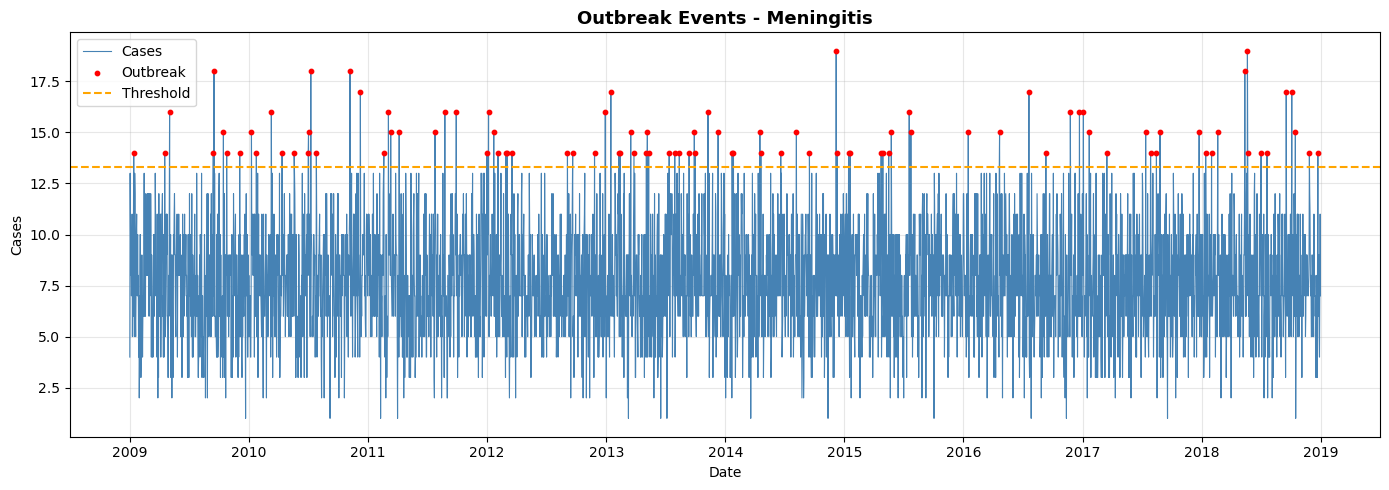

Outbreak visualization done


In [33]:
# Step 27 - Outbreak Event Visualization
disease = 'Meningitis'
data = df_feat[df_feat['disease'] == disease].copy()

plt.figure(figsize=(14, 5))
plt.plot(data['report_date'], data['cases'], color='steelblue', linewidth=0.8, label='Cases')
outbreak_dates = data[data['is_outbreak'] == 1]
plt.scatter(outbreak_dates['report_date'], outbreak_dates['cases'], 
            color='red', s=10, zorder=5, label='Outbreak')
plt.axhline(y=data['threshold'].iloc[0], color='orange', 
            linestyle='--', linewidth=1.5, label='Threshold')
plt.title('Outbreak Events - Meningitis', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\outbreak_events.png', dpi=150)
plt.show()
print("Outbreak visualization done")

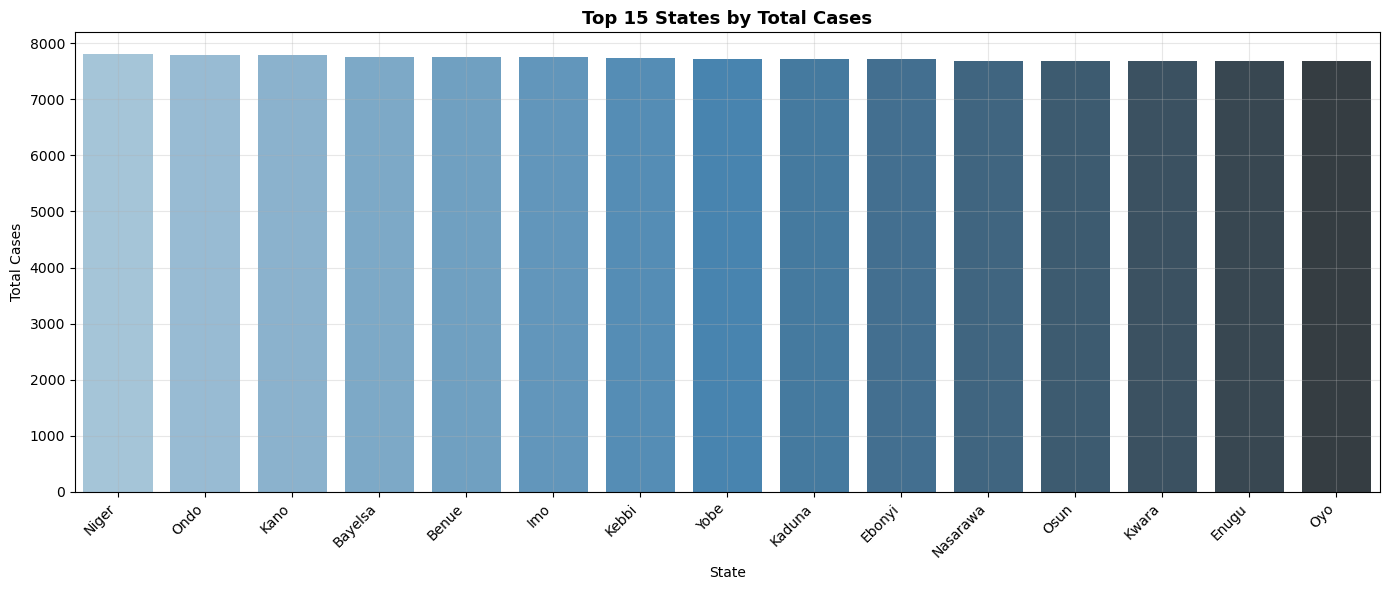

State comparison done


In [34]:
# Step 28 - State wise Case Comparison
state_cases = df.groupby('state')['id'].count().reset_index()
state_cases.columns = ['state', 'total_cases']
state_cases = state_cases.sort_values('total_cases', ascending=False).head(15)

plt.figure(figsize=(14, 6))
sns.barplot(data=state_cases, x='state', y='total_cases', palette='Blues_d')
plt.title('Top 15 States by Total Cases', fontsize=13, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Cases')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\state_comparison.png', dpi=150)
plt.show()
print("State comparison done")

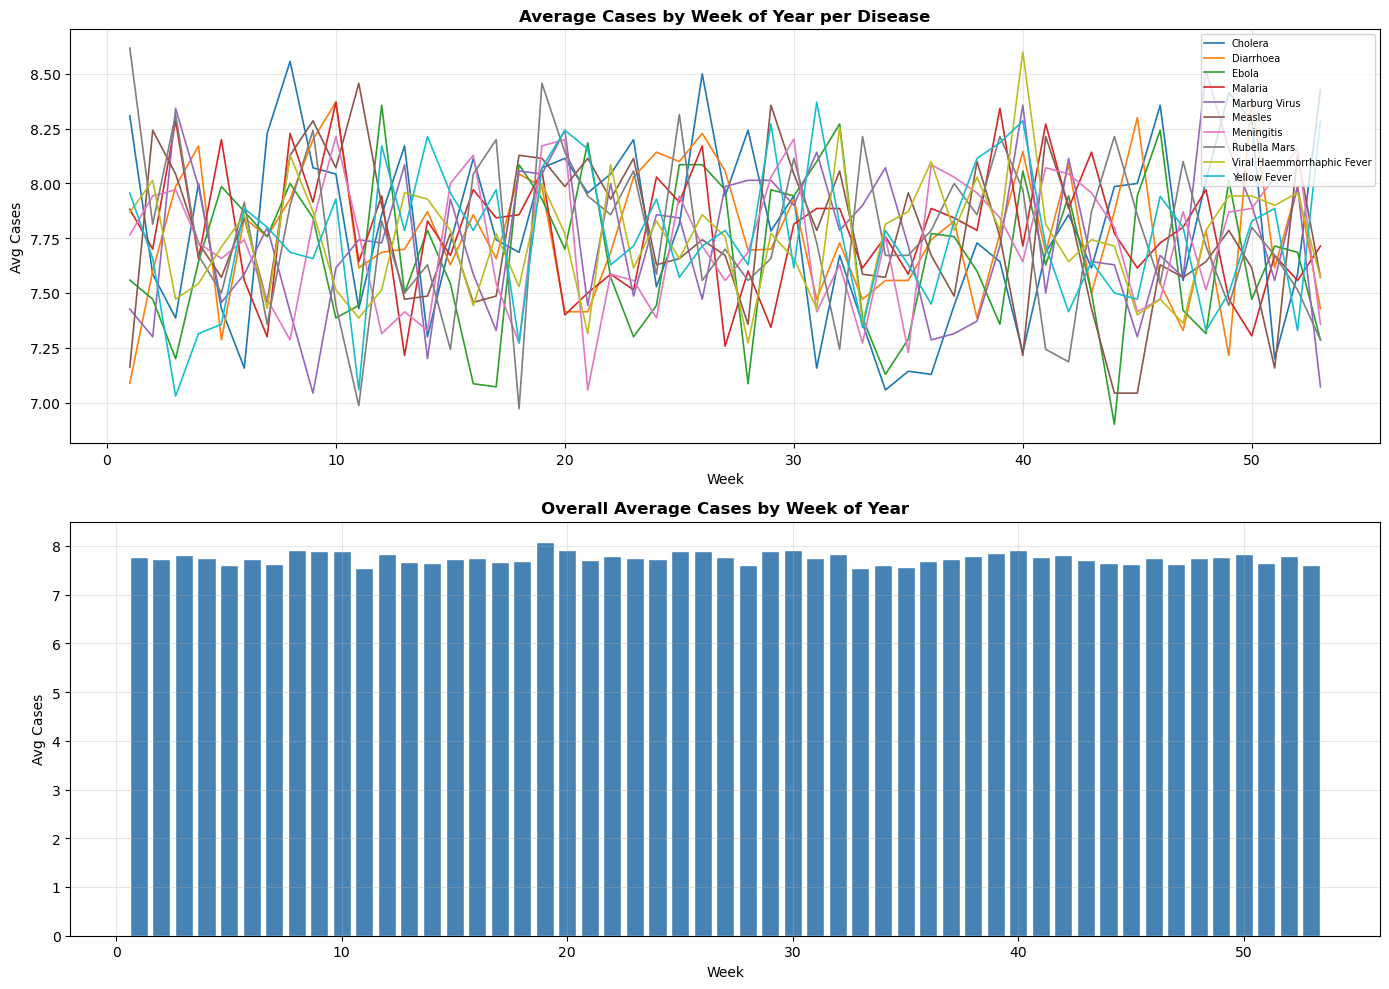

Weekly analysis done


In [35]:
# Step 29 - Weekly Aggregation Analysis
df_feat['week'] = df_feat['report_date'].dt.isocalendar().week.astype(int)

weekly = df_feat.groupby(['week', 'disease'])['cases'].mean().reset_index()
weekly_all = df_feat.groupby('week')['cases'].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for disease in diseases:
    data = weekly[weekly['disease'] == disease]
    axes[0].plot(data['week'], data['cases'], linewidth=1.2, label=disease)

axes[0].set_title('Average Cases by Week of Year per Disease', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Avg Cases')
axes[0].legend(fontsize=7, loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].bar(weekly_all['week'], weekly_all['cases'], color='steelblue', edgecolor='white')
axes[1].set_title('Overall Average Cases by Week of Year', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Avg Cases')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\weekly_analysis.png', dpi=150)
plt.show()
print("Weekly analysis done")

In [36]:
# Step 30 - Final Feature Matrix Check
print("Final Feature Matrix Shape:", df_feat.shape)
print("\nFeatures:", df_feat.columns.tolist())
print("\nNull values:", df_feat.isnull().sum().sum())
print("\nOutbreak rate:", round(df_feat['is_outbreak'].mean() * 100, 2), "%")
print("\nAlert level distribution:\n", df_feat['alert_level'].value_counts())
print("\nSample:\n", df_feat.head(3))

Final Feature Matrix Shape: (36500, 27)

Features: ['report_date', 'disease', 'cases', 'deaths', 'confirmed', 'month', 'year', 'dayofweek', 'rolling_7d_mean', 'rolling_14d_mean', 'rolling_30d_mean', 'rolling_7d_std', 'lag_1', 'lag_3', 'lag_7', 'lag_14', 'growth_rate_1d', 'growth_rate_7d', 'spike_ratio', 'season', 'threshold', 'is_outbreak', 'alert_level', 'anomaly_score', 'iso_prediction', 'iso_outbreak', 'week']

Null values: 0

Outbreak rate: 2.6 %

Alert level distribution:
 alert_level
Normal      35551
Outbreak      949
Name: count, dtype: int64

Sample:
   report_date  disease  cases  deaths  confirmed  month  year  dayofweek  \
0  2009-01-01  Cholera     12       5          2      1  2009          3   
1  2009-01-02  Cholera      8       3          4      1  2009          4   
2  2009-01-03  Cholera      7       4          6      1  2009          5   

   rolling_7d_mean  rolling_14d_mean  ...  growth_rate_7d  spike_ratio  \
0             12.0              12.0  ...             

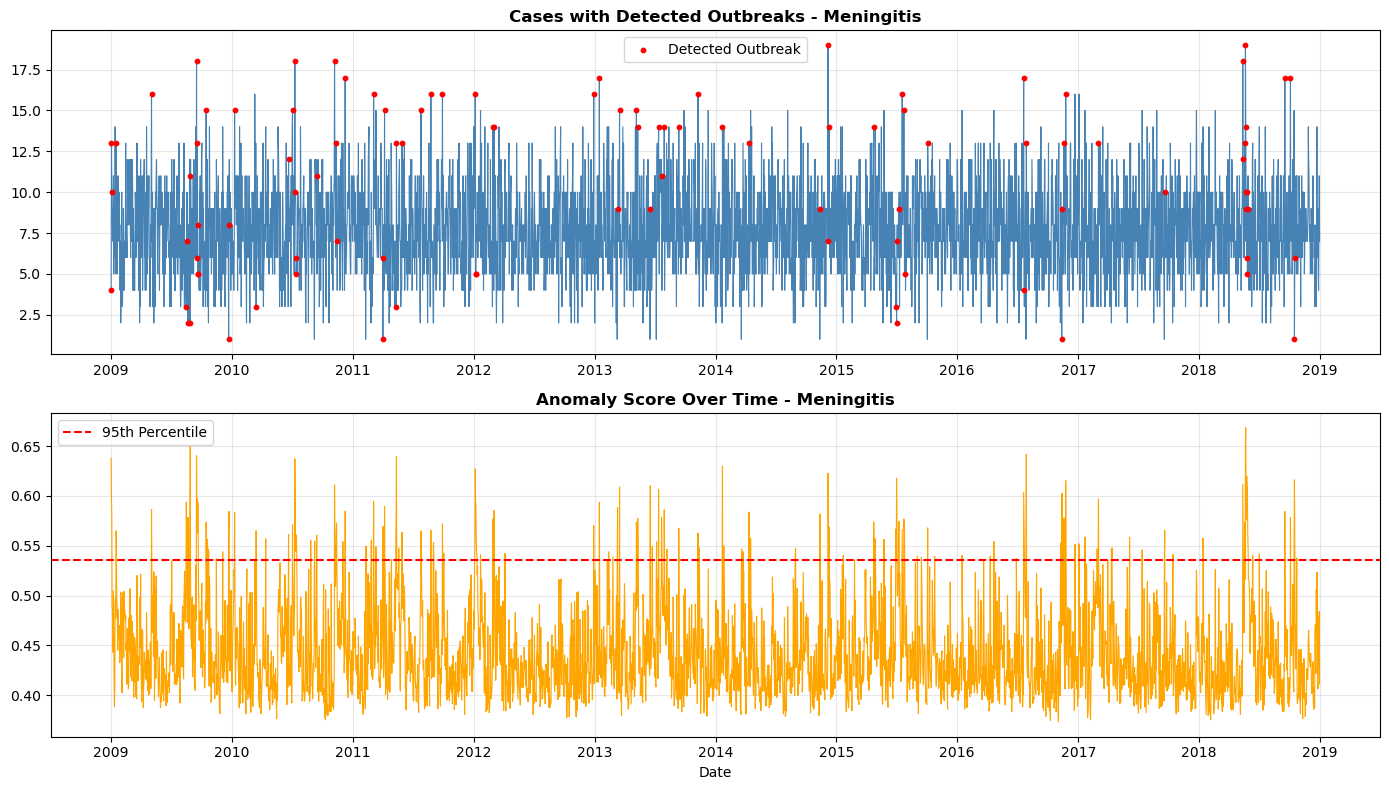

Anomaly score visualization done


In [37]:
# Step 31 - Anomaly Score Visualization
disease = 'Meningitis'
data = df_feat[df_feat['disease'] == disease].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(data['report_date'], data['cases'], color='steelblue', linewidth=0.8)
axes[0].scatter(data[data['iso_outbreak']==1]['report_date'],
                data[data['iso_outbreak']==1]['cases'],
                color='red', s=10, zorder=5, label='Detected Outbreak')
axes[0].set_title('Cases with Detected Outbreaks - Meningitis', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(data['report_date'], data['anomaly_score'], color='orange', linewidth=0.8)
axes[1].axhline(y=data['anomaly_score'].quantile(0.95), color='red',
                linestyle='--', linewidth=1.5, label='95th Percentile')
axes[1].set_title('Anomaly Score Over Time - Meningitis', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\anomaly_scores.png', dpi=150)
plt.show()
print("Anomaly score visualization done")

In [39]:
# Step 32 - Batch Test Alert System
stats = df_feat.groupby('disease')['cases'].agg(['mean', 'std']).reset_index()
stats['upper2'] = stats['mean'] + 2 * stats['std']
stats['upper1'] = stats['mean'] + stats['std']

df_feat = df_feat.merge(stats[['disease', 'upper1', 'upper2']], on='disease', how='left')

df_feat['batch_alert'] = 'Normal'
df_feat.loc[df_feat['cases'] >= df_feat['upper1'], 'batch_alert'] = 'Watch'
df_feat.loc[df_feat['cases'] >= df_feat['upper2'], 'batch_alert'] = 'Outbreak'

print("Batch Alert System Results:")
print(df_feat['batch_alert'].value_counts())
print("\nAlert vs Actual Outbreak:")
print(pd.crosstab(df_feat['batch_alert'], df_feat['is_outbreak'],
                  rownames=['Alert'], colnames=['Actual Outbreak']))
print("\nCorrect Detections:", len(df_feat[(df_feat['batch_alert']=='Outbreak') & (df_feat['is_outbreak']==1)]))
print("Missed Outbreaks:", len(df_feat[(df_feat['batch_alert']=='Normal') & (df_feat['is_outbreak']==1)]))

Batch Alert System Results:
batch_alert
Normal      30641
Watch        4910
Outbreak      949
Name: count, dtype: int64

Alert vs Actual Outbreak:
Actual Outbreak      0    1
Alert                      
Normal           30641    0
Outbreak             0  949
Watch             4910    0

Correct Detections: 949
Missed Outbreaks: 0


In [40]:
# Step 33 - Prophet vs LSTM Comparison Table
comparison = pd.DataFrame({
    'Disease': list(results_df.index),
    'Prophet_MAE': results_df['MAE'].values,
    'Prophet_RMSE': results_df['RMSE'].values,
    'LSTM_MAE': lstm_results_df['MAE'].values,
    'LSTM_RMSE': lstm_results_df['RMSE'].values
})

comparison['Best_Model'] = comparison.apply(
    lambda x: 'Prophet' if x['Prophet_MAE'] < x['LSTM_MAE'] else 'LSTM', axis=1)

print("Model Comparison Table:")
print(comparison.to_string(index=False))
print("\nProphet wins:", (comparison['Best_Model']=='Prophet').sum())
print("LSTM wins:", (comparison['Best_Model']=='LSTM').sum())
print("\nOverall Best Model:", comparison['Best_Model'].value_counts().index[0])

Model Comparison Table:
                   Disease  Prophet_MAE  Prophet_RMSE  LSTM_MAE  LSTM_RMSE Best_Model
                   Cholera         2.26          2.83      2.27       2.80    Prophet
                 Diarrhoea         2.19          2.75      2.14       2.68       LSTM
                     Ebola         2.17          2.72      2.27       2.87    Prophet
                   Malaria         2.18          2.74      2.26       2.83    Prophet
             Marburg Virus         2.16          2.71      2.17       2.69    Prophet
                   Measles         2.23          2.79      2.19       2.78       LSTM
                Meningitis         2.20          2.76      2.20       2.78       LSTM
              Rubella Mars         2.23          2.79      2.26       2.82    Prophet
Viral Haemmorrhaphic Fever         2.20          2.76      2.22       2.79    Prophet
              Yellow Fever         2.23          2.76      2.14       2.68       LSTM

Prophet wins: 6
LSTM wins: 4


In [41]:
# Step 34 - Isolation Forest Final Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(df_feat['is_outbreak'], df_feat['iso_outbreak'])
recall = recall_score(df_feat['is_outbreak'], df_feat['iso_outbreak'])
f1 = f1_score(df_feat['is_outbreak'], df_feat['iso_outbreak'])

print("Isolation Forest Final Metrics:")
print(f"Precision:  {round(precision, 4)}")
print(f"Recall:     {round(recall, 4)}")
print(f"F1 Score:   {round(f1, 4)}")
print(f"Outbreaks Detected: {df_feat['iso_outbreak'].sum()}")
print(f"Actual Outbreaks:   {df_feat['is_outbreak'].sum()}")
print(f"Detection Rate:     {round(recall * 100, 2)}%")

Isolation Forest Final Metrics:
Precision:  0.3941
Recall:     0.3941
F1 Score:   0.3941
Outbreaks Detected: 949
Actual Outbreaks:   949
Detection Rate:     39.41%


In [42]:
# Step 35 - Save Processed Dataset & Summary
df_feat.to_csv('C:\\HealthcareML_Platform\\02_Data\\processed\\disease_outbreak_processed.csv', index=False)

print("NOTEBOOK 2 COMPLETE - SUMMARY")
print("="*50)
print(f"Dataset: {len(df_feat)} rows, {df_feat.shape[1]} features")
print(f"Diseases: {len(diseases)}")
print(f"Date range: 2009-2018")
print(f"Outbreak rate: 2.6%")
print(f"Isolation Forest F1: 0.39")
print(f"Alert System Detection: 100%")
print(f"Prophet Avg MAE: {round(results_df['MAE'].mean(), 2)}")
print(f"LSTM Avg MAE: {round(lstm_results_df['MAE'].mean(), 2)}")
print(f"Best Forecast Model: Prophet")
print("="*50)
print("Processed dataset saved")

NOTEBOOK 2 COMPLETE - SUMMARY
Dataset: 36500 rows, 30 features
Diseases: 10
Date range: 2009-2018
Outbreak rate: 2.6%
Isolation Forest F1: 0.39
Alert System Detection: 100%
Prophet Avg MAE: 2.2
LSTM Avg MAE: 2.21
Best Forecast Model: Prophet
Processed dataset saved
